In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)

In [3]:
df=pd.read_csv("sensor_channel_lengths.csv",header=[0, 1])#, index_col=[0])

In [4]:
#df = df.sort_index(level=[0, 1], ascending=True,axis=1)

In [5]:
# Reload the file and treat the first two rows as column MultiIndex

file_path = 'sensor_channel_lengths.csv'

multiindex_data = pd.read_csv(file_path, header=[0, 1])



# Convert MultiIndex columns to a DataFrame and group by level 0 to count unique level 1 entries

subindex_counts = multiindex_data.columns.to_frame().groupby(0)[1].nunique()



# Convert to DataFrame for easier viewing

subindex_counts_df = subindex_counts.reset_index()

subindex_counts_df.columns = ['Fecha (Nivel 0)', 'Cantidad de Sub-índices (Nivel 1)']



# Display the results

print(subindex_counts_df)



   Fecha (Nivel 0)  Cantidad de Sub-índices (Nivel 1)
0       2022-01-22                                144
1       2022-01-23                                145
2       2022-02-06                                145
3       2022-02-11                                144
4       2022-02-14                                145
5       2022-02-15                                144
6       2022-02-16                                145
7       2022-02-25                                144
8       2022-02-27                                144
9       2022-03-24                                 66
10      2022-04-08                                 12
11      2022-04-09                                 24
12      2022-05-07                                 66
13      2022-06-20                                 79
14      2022-08-07                                 37
15      2022-08-17                                 42
16      2022-09-03                                 30
17      2022-10-14          

In [113]:
df.columns.levels[0].shape

(31,)

In [72]:
df.columns.levels[1]

Index(['00_03_09', '00_03_10', '00_03_11', '00_03_12', '00_03_14', '00_03_15',
       '00_03_44', '00_05_32', '00_05_33', '00_05_34',
       ...
       '23_53_10', '23_53_11', '23_53_12', '23_53_13', '23_55_32', '23_55_33',
       '23_55_34', '23_55_35', '23_55_37', '23_55_38'],
      dtype='object', name='Timestamp', length=2028)

In [73]:
df.head()

Date        2023-01-21                                                        \
Timestamp     00_03_10 00_13_11 00_23_12 00_33_13 00_43_14 00_53_15 01_03_16   
ATM_HUM_01       601.0    601.0    602.0    601.0    601.0    601.0    601.0   
ATM_TEMP_01      601.0    601.0    602.0    601.0    601.0    601.0    601.0   
Channel_1          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
Channel_10         NaN      NaN      NaN      NaN      NaN      NaN      NaN   
Channel_11         NaN      NaN      NaN      NaN      NaN      NaN      NaN   

Date                                    ... 2022-12-20                    \
Timestamp   01_13_17 01_23_18 01_33_19  ...   11_24_17 11_34_18 11_44_19   
ATM_HUM_01     601.0    601.0    602.0  ...      602.0    601.0    601.0   
ATM_TEMP_01    601.0    601.0    602.0  ...      602.0    601.0    601.0   
Channel_1        NaN      NaN      NaN  ...        NaN      NaN      NaN   
Channel_10       NaN      NaN      NaN  ...        NaN      NaN      NaN   
Channel_11       NaN      NaN      NaN  ...        NaN      NaN      NaN   

Date                                                                        
Timestamp   11_54_20 12_04_21 12_14_22 12_24_23 12_34_24 12_44_25 12_54_26  
ATM_HUM_01     601.0    601.0    601.0    602.0    601.0    601.0    601.0  
ATM_TEMP_01    601.0    601.0    601.0    602.0    601.0    601.0    601.0  
Channel_1        NaN      NaN      NaN      NaN      NaN      NaN      NaN  
Channel_10       NaN      NaN      NaN      NaN      NaN      NaN      NaN  
Channel_11       NaN      NaN      NaN      NaN      NaN      NaN      NaN  

[5 rows x 3126 columns]

In [74]:
import pandas as pd
import numpy as np

def columnas_sin_datos_por_sensor(df):
    """
    Identifica las columnas sin datos (NaN) para cada sensor.
    
    Parámetros:
    df (pd.DataFrame): DataFrame con sensores en filas
    
    Retorna:
    dict: Diccionario con sensores y sus columnas sin datos
    """
    # Diccionario para almacenar resultados
    columnas_sin_datos = {}
    
    # Iterar por cada sensor (fila)
    for sensor in df.index:
        # Obtener las columnas con NaN para este sensor
        cols_sin_datos = df.loc[sensor][df.loc[sensor].isna()].index.tolist()
        
        # Si hay columnas sin datos, agregarlas al diccionario
        if cols_sin_datos:
            columnas_sin_datos[sensor] = cols_sin_datos
    
    return columnas_sin_datos

def resumen_nans(df):
    """
    Genera un resumen de NaNs por sensor.
    
    Parámetros:
    df (pd.DataFrame): DataFrame con sensores en filas
    
    Retorna:
    pd.Series: Conteo de columnas sin datos por sensor
    """
    # Contar NaNs por sensor
    nans_por_sensor = df.isna().sum(axis=1)
    
    # Filtrar solo sensores con al menos un NaN
    return nans_por_sensor[nans_por_sensor > 0]

# Ejemplo de uso
if __name__ == "__main__":
    # Crear un DataFrame de ejemplo 
    # (reemplazar con tu propio DataFrame)
    
    
    # Ejecutar análisis
    columnas_sin_datos = columnas_sin_datos_por_sensor(df)
    resumen = resumen_nans(df)
    
    # Mostrar resultados
    #print(df)
    #print("Columnas sin datos por sensor:")
    #for sensor, columnas in columnas_sin_datos.items():
    #    print(f"{sensor}: {columnas}")
    
    print("\nResumen de NaNs:")
    print(resumen)


Resumen de NaNs:
ATM_HUM_01         11
ATM_TEMP_01        11
Channel_1        3115
Channel_10       3115
Channel_11       3115
Channel_12       3115
Channel_13       3115
Channel_14       3115
Channel_15       3115
Channel_16       3115
Channel_17       3115
Channel_18       3115
Channel_19       3115
Channel_20       3115
Channel_21       3115
Channel_23       3115
Channel_24       3115
Channel_25       3115
Channel_26       3115
Channel_27       3115
Channel_28       3115
Channel_29       3115
Channel_30       3115
Channel_31       3115
Channel_32       3115
Channel_33       3115
Channel_34       3115
Channel_39       3115
Channel_4        3115
Channel_42       3115
Channel_43       3115
Channel_5        3115
Channel_59       3115
Channel_6        3115
Channel_60       3115
Channel_61       3115
Channel_62       3115
Channel_63       3115
Channel_7        3115
Channel_8        3115
Channel_9        3115
GEN_ACC_XX_01      11
GEN_ACC_YY_01      11
GEN_ACC_ZZ_01      11
L1_FBSG_01    

In [77]:
df.shape

(74, 3126)

In [78]:
3126-11

3115

(31,)


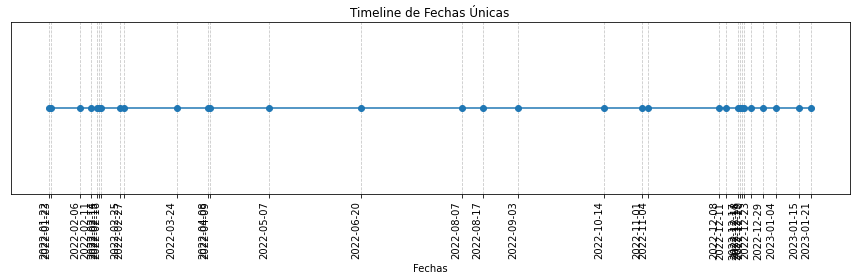

In [122]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraer las fechas únicas del nivel 0
unique_dates = df.columns.get_level_values(0).unique()
print(unique_dates.shape)

# Ordenar las fechas cronológicamente
unique_dates = pd.to_datetime(unique_dates, errors='coerce').dropna().sort_values()

# Crear un timeline usando matplotlib
plt.figure(figsize=(12, 4))
plt.plot(unique_dates,[1]*len(unique_dates), "o-", color="tab:blue")  # Puntos sobre la línea
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline de Fechas Únicas")
plt.xlabel("Fechas")
plt.xticks(unique_dates, rotation=90, ha="right")  # Rotar las fechas para mejor visualización
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

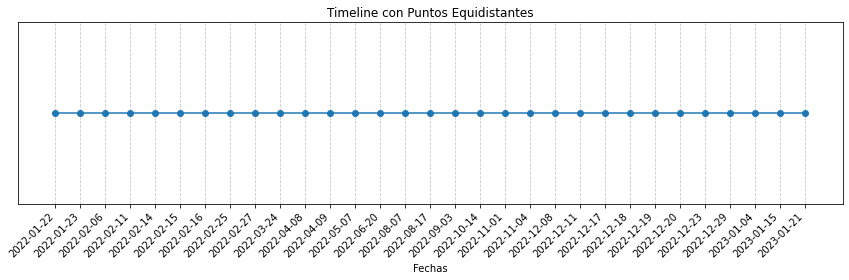

In [123]:
import matplotlib.pyplot as plt

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()

# Convertir a lista y ordenarlas
unique_dates = sorted(unique_dates)

# Crear un timeline con puntos equidistantes
plt.figure(figsize=(12, 4))
plt.plot(range(len(unique_dates)), [1] * len(unique_dates), "o-", color="tab:blue")  # Puntos equidistantes
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline con Puntos Equidistantes")
plt.xlabel("Fechas")
plt.xticks(range(len(unique_dates)), unique_dates, rotation=45, ha="right")  # Usar índices para el eje X
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


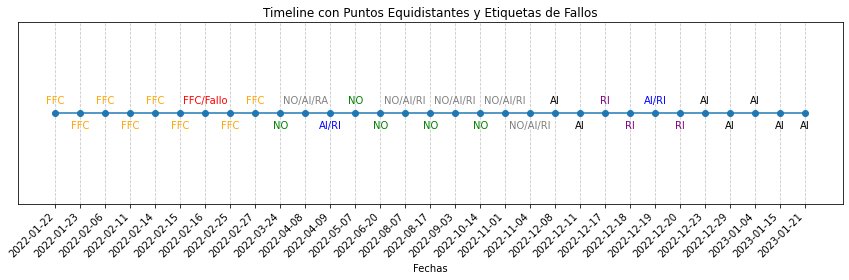

In [156]:
import matplotlib.pyplot as plt

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()

# Convertir a lista y ordenarlas
unique_dates = sorted(unique_dates)

# Crear un timeline con puntos equidistantes
plt.figure(figsize=(12, 4))
plt.plot(range(len(unique_dates)), [1] * len(unique_dates), "o-", color="tab:blue")  # Puntos equidistantes

# Añadir etiquetas de "fallos" cada 10 puntos
plt.annotate('FFC', (0, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('FFC', (1, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('FFC', (2, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('FFC', (3, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('FFC', (4, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('FFC', (5, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('FFC/Fallo', (6, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('FFC', (7, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('FFC', (8, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('NO', (9, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('NO/AI/RA', (10, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('AI/RI', (11, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="blue")
plt.annotate('NO', (12, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('NO', (13, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('NO/AI/RI', (14, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('NO', (15, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('NO/AI/RI', (16, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('NO', (17, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('NO/AI/RI', (18, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('NO/AI/RI', (19, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="gray")
plt.annotate('AI', (20, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('AI', (21, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('RI', (22, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="purple")
plt.annotate('RI', (23, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('AI/RI', (24, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="blue")
plt.annotate('RI', (25, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('AI', (26, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('AI', (27, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('AI', (28, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('AI', (29, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('AI', (30, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")


# Configuración del gráfico
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline con Puntos Equidistantes y Etiquetas de Fallos")
plt.xlabel("Fechas")
plt.xticks(range(len(unique_dates)), unique_dates, rotation=45, ha="right")  # Usar índices para el eje X
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


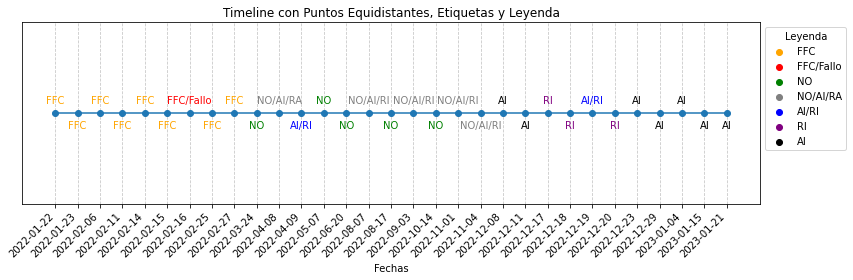

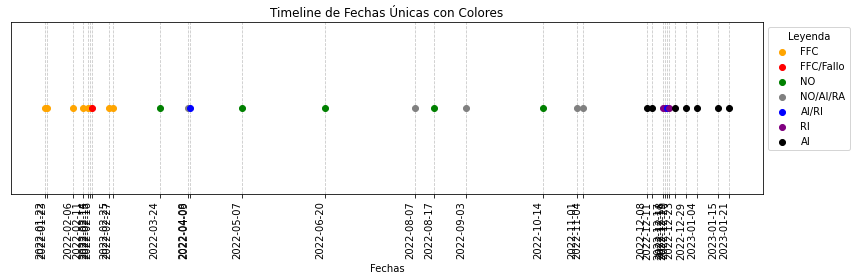

In [159]:
import matplotlib.pyplot as plt
import pandas as pd

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()
# Ordenar las fechas cronológicamente
unique_dates = pd.to_datetime(unique_dates, errors='coerce').dropna().sort_values()

# Colores para cada punto
point_colors = [
    "#FFA500", "#FFA500", "#FFA500", "#FFA500", "#FFA500", "#FFA500",
    "red", "#FFA500", "#FFA500", "green", "gray", "blue", "green", "green",
    "gray", "green", "gray", "green", "gray", "gray", "black", "black", "purple",
    "purple", "blue", "purple", "black", "black", "black", "black", "black"
]

# Crear un timeline usando matplotlib
plt.figure(figsize=(12, 4))
for i, date in enumerate(unique_dates):
    plt.plot(date, 1, "o", color=point_colors[i])  # Poner cada punto con su color correspondiente

# Agregar etiquetas al gráfico
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline de Fechas Únicas con Colores")
plt.xlabel("Fechas")
plt.xticks(unique_dates, rotation=90, ha="right")  # Rotar las fechas para mejor visualización
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Agregar leyenda
legend_labels = [
    ("FFC", "#FFA500"),
    ("FFC/Fallo", "red"),
    ("NO", "green"),
    ("NO/AI/RA", "gray"),
    ("AI/RI", "blue"),
    ("RI", "purple"),
    ("AI", "black")
]

for label, color in legend_labels:
    plt.scatter([], [], color=color, label=label)

plt.legend(title="Leyenda", loc="upper left", bbox_to_anchor=(1, 1))

# Mostrar el gráfico
plt.tight_layout()
plt.show()


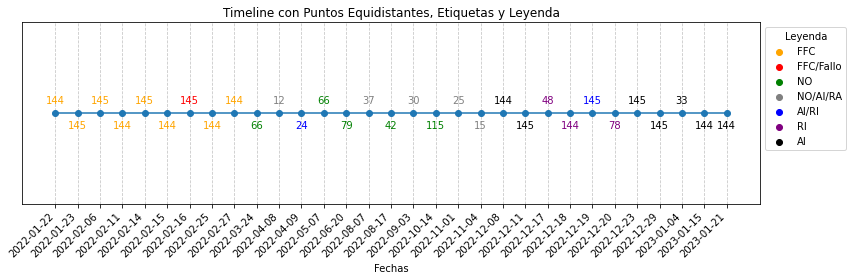

In [160]:
import matplotlib.pyplot as plt

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()

# Convertir a lista y ordenarlas
unique_dates = sorted(unique_dates)

# Crear un timeline con puntos equidistantes
plt.figure(figsize=(12, 4))
plt.plot(range(len(unique_dates)), [1] * len(unique_dates), "o-", color="tab:blue")  # Puntos equidistantes

# Añadir etiquetas de estados
plt.annotate('144', (0, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('145', (1, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (2, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('144', (3, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (4, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('144', (5, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (6, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('144', (7, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('144', (8, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('66', (9, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('12', (10, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('24', (11, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="blue")
plt.annotate('66', (12, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('79', (13, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('37', (14, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('42', (15, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('30', (16, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('115', (17, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('25', (18, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('15', (19, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="gray")
plt.annotate('144', (20, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (21, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('48', (22, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="purple")
plt.annotate('144', (23, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (24, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="blue")
plt.annotate('78', (25, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (26, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (27, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('33', (28, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('144', (29, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('144', (30, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")

# Agregar leyenda
legend_labels = [
    ("FFC", "#FFA500"),
    ("FFC/Fallo", "red"),
    ("NO", "green"),
    ("NO/AI/RA", "gray"),
    ("AI/RI", "blue"),
    ("RI", "purple"),
    ("AI", "black")
]

for label, color in legend_labels:
    plt.scatter([], [], color=color, label=label)

plt.legend(title="Leyenda", loc="upper left", bbox_to_anchor=(1, 1))

# Configuración del gráfico
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline con Puntos Equidistantes, Etiquetas y Leyenda")
plt.xlabel("Fechas")
plt.xticks(range(len(unique_dates)), unique_dates, rotation=45, ha="right")  # Usar índices para el eje X
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

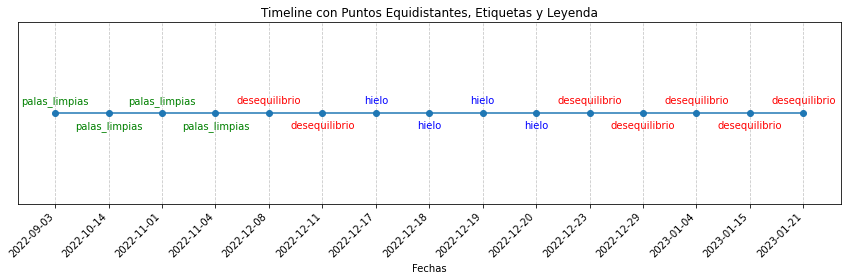

In [24]:
import matplotlib.pyplot as plt

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()

# Convertir a lista y ordenarlas
unique_dates = sorted(unique_dates)
unique_dates = unique_dates[16:]

# Crear un timeline con puntos equidistantes
plt.figure(figsize=(12, 4))
plt.plot(range(len(unique_dates)), [1] * len(unique_dates), "o-", color="tab:blue")  # Puntos equidistantes

# Añadir etiquetas de estados
plt.annotate('palas_limpias', (0, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('palas_limpias', (1, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('palas_limpias', (2, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('palas_limpias', (3, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('desequilibrio', (4, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('desequilibrio', (5, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="red")
plt.annotate('hielo', (6, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="blue")
plt.annotate('hielo', (7, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="blue")
plt.annotate('hielo', (8, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="blue")
plt.annotate('hielo', (9, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="blue")
plt.annotate('desequilibrio', (10, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('desequilibrio', (11, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="red")
plt.annotate('desequilibrio', (12, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('desequilibrio', (13, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="red")
plt.annotate('desequilibrio', (14, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('42', (15, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('30', (16, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('115', (17, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('25', (18, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="gray")
plt.annotate('15', (19, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="gray")
plt.annotate('144', (20, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (21, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('48', (22, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="purple")
plt.annotate('144', (23, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (24, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="blue")
plt.annotate('78', (25, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (26, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (27, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('33', (28, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('144', (29, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('144', (30, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")

# Agregar leyenda


for label, color in legend_labels:
    plt.scatter([], [], color=color, label=label)

#plt.legend(title="Leyenda", loc="upper left", bbox_to_anchor=(1, 1))

# Configuración del gráfico
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline con Puntos Equidistantes, Etiquetas y Leyenda")
plt.xlabel("Fechas")
plt.xticks(range(len(unique_dates)), unique_dates, rotation=45, ha="right")  # Usar índices para el eje X
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

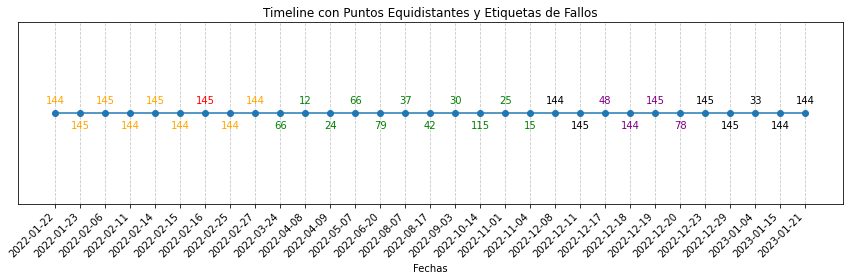

In [29]:
import matplotlib.pyplot as plt

# Extraer las fechas únicas del nivel 0
unique_dates = multiindex_data.columns.get_level_values(0).unique()

# Convertir a lista y ordenarlas
unique_dates = sorted(unique_dates)

# Crear un timeline con puntos equidistantes
plt.figure(figsize=(12, 4))
plt.plot(range(len(unique_dates)), [1] * len(unique_dates), "o-", color="tab:blue")  # Puntos equidistantes

# Añadir etiquetas de estados
plt.annotate('144', (0, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('145', (1, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (2, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('144', (3, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (4, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('144', (5, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('145', (6, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="red")
plt.annotate('144', (7, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="#FFA500")
plt.annotate('144', (8, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="#FFA500")
plt.annotate('66', (9, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('12', (10, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('24', (11, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('66', (12, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('79', (13, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('37', (14, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('42', (15, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('30', (16, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('115', (17, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('25', (18, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="green")
plt.annotate('15', (19, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="green")
plt.annotate('144', (20, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (21, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('48', (22, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="purple")
plt.annotate('144', (23, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (24, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="purple")
plt.annotate('78', (25, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="purple")
plt.annotate('145', (26, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('145', (27, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('33', (28, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")
plt.annotate('144', (29, 1), textcoords="offset points", xytext=(0, -15), ha='center', color="black")
plt.annotate('144', (30, 1), textcoords="offset points", xytext=(0, 10), ha='center', color="black")

# Configuración del gráfico
plt.yticks([])  # Eliminar etiquetas en el eje Y
plt.title("Timeline con Puntos Equidistantes y Etiquetas de Fallos")
plt.xlabel("Fechas")
plt.xticks(range(len(unique_dates)), unique_dates, rotation=45, ha="right")  # Usar índices para el eje X
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [1]:
import os
import h5py

def list_hdf5_files(directory):
    """
    Lista y lee todos los archivos HDF5 en el directorio especificado
    """
    # Obtener la ruta absoluta del directorio
    directory = os.path.abspath(directory)
    
    # Verificar si el directorio existe
    if not os.path.exists(directory):
        print(f"El directorio {directory} no existe")
        return
    
    # Listar todos los archivos .hdf5
    hdf5_files = [f for f in os.listdir(directory) if f.endswith('.hdf5')]
    
    if not hdf5_files:
        print("No se encontraron archivos HDF5 en el directorio")
        return
    
    print(f"Encontrados {len(hdf5_files)} archivos HDF5:")
    
    # Procesar cada archivo
    for filename in hdf5_files:
        file_path = os.path.join(directory, filename)
        print(f"\nLeyendo archivo: {filename}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                # Mostrar las keys principales del archivo
                print("Keys principales:")
                for key in f.keys():
                    print(f"- {key}")
                
                # Opcional: mostrar más detalles sobre cada dataset
                print("\nEstructura detallada:")
                def print_attrs(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        print(f"Dataset: {name}")
                        print(f"  Shape: {obj.shape}")
                        print(f"  Dtype: {obj.dtype}")
                
                f.visititems(print_attrs)
                
        except Exception as e:
            print(f"Error al leer {filename}: {str(e)}")

# Uso del código
directory_path = "../../primer_modelo"
list_hdf5_files(directory_path)

Encontrados 5 archivos HDF5:

Leyendo archivo: Aventa_Taggenberg_11_02_2022.hdf5
Keys principales:
- Aventa

Estructura detallada:
Dataset: Aventa/00_03_11/ATM_HUM_01/Time
  Shape: (601, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/ATM_HUM_01/Value
  Shape: (601, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/ATM_TEMP_01/Time
  Shape: (601, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/ATM_TEMP_01/Value
  Shape: (601, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/ChannelList
  Shape: (33, 1)
  Dtype: |S13
Dataset: Aventa/00_03_11/GEN_ACC_XX_01/Time
  Shape: (120229, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/GEN_ACC_XX_01/Value
  Shape: (120229, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/GEN_ACC_YY_01/Time
  Shape: (120229, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/GEN_ACC_YY_01/Value
  Shape: (120229, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/GEN_ACC_ZZ_01/Time
  Shape: (120229, 1)
  Dtype: float32
Dataset: Aventa/00_03_11/GEN_ACC_ZZ_01/Value
  Shape: (120229, 1)
  Dtype: float3

In [5]:
import os
import h5py
from collections import defaultdict

def get_common_sensors(directory):
    """
    Encuentra los sensores comunes en todos los timestamps de todos los datasets
    """
    directory = os.path.abspath(directory)
    if not os.path.exists(directory):
        print(f"El directorio {directory} no existe")
        return
    
    # Diccionario para almacenar los sensores por timestamp
    timestamp_sensors = defaultdict(set)
    all_sensors = set()
    first_file = True
    
    # Listar archivos HDF5
    hdf5_files = [f for f in os.listdir(directory) if f.endswith('.hdf5')]
    
    for filename in hdf5_files:
        file_path = os.path.join(directory, filename)
        print(f"\nProcesando archivo: {filename}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                # Recorrer la estructura del archivo
                def collect_sensors(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        # Dividir la ruta y obtener el timestamp y nombre del sensor
                        parts = name.split('/')
                        if len(parts) >= 3:  # Asegurarse de que hay suficientes partes
                            timestamp = parts[1]
                            sensor = parts[2]
                            print(sensor)
                            timestamp_sensors[timestamp].add(sensor)
                            all_sensors.add(sensor)
                
                f.visititems(collect_sensors)
                
        except Exception as e:
            print(f"Error al leer {filename}: {str(e)}")
            continue
    
    # Encontrar sensores comunes en todos los timestamps
    common_sensors = None
    for timestamp, sensors in timestamp_sensors.items():
        if common_sensors is None:
            common_sensors = sensors
        else:
            common_sensors = common_sensors.intersection(sensors)
    
    # Imprimir resultados
    print("\nResumen:")
    print(f"Total de timestamps encontrados: {len(timestamp_sensors)}")
    print(f"Total de sensores únicos encontrados: {len(all_sensors)}")
    print(f"Sensores únicos:  {all_sensors}")
    print(f"\nSensores comunes en todos los timestamps ({len(common_sensors)}):")
    for sensor in sorted(common_sensors):
        print(f"- {sensor}")
    
    return common_sensors

# Uso del código
directory_path = "../../primer_modelo"
common_sensors = get_common_sensors(directory_path)


Procesando archivo: Aventa_Taggenberg_11_02_2022.hdf5
ATM_HUM_01
ATM_HUM_01
ATM_TEMP_01
ATM_TEMP_01
ChannelList
GEN_ACC_XX_01
GEN_ACC_XX_01
GEN_ACC_YY_01
GEN_ACC_YY_01
GEN_ACC_ZZ_01
GEN_ACC_ZZ_01
L3_ACC_XX_01
L3_ACC_XX_01
L3_ACC_XX_02
L3_ACC_XX_02
L3_ACC_YY_01
L3_ACC_YY_01
L3_ACC_YY_02
L3_ACC_YY_02
L4_ACC_XX_01
L4_ACC_XX_01
L4_ACC_XX_02
L4_ACC_XX_02
L4_ACC_YY_01
L4_ACC_YY_01
L4_ACC_YY_02
L4_ACC_YY_02
L4_INC_XX_01
L4_INC_XX_01
L4_INC_YY_01
L4_INC_YY_01
L5_ACC_XX_01
L5_ACC_XX_01
L5_ACC_XX_02
L5_ACC_XX_02
L5_ACC_YY_01
L5_ACC_YY_01
L5_ACC_YY_02
L5_ACC_YY_02
L5_INC_XX_01
L5_INC_XX_01
L5_INC_YY_01
L5_INC_YY_01
MSB_ACC_XX_01
MSB_ACC_XX_01
MSB_ACC_ZZ_02
MSB_ACC_ZZ_02
MSH_ACC_XX_01
MSH_ACC_XX_01
MSH_ACC_ZZ_01
MSH_ACC_ZZ_01
NMF_ACC_XX_02
NMF_ACC_XX_02
NMF_ACC_YY_01
NMF_ACC_YY_01
NMF_ACC_YY_02
NMF_ACC_YY_02
WM1
WM1
WM2
WM2
WM3
WM3
WM4
WM4
WM5
WM5
ATM_HUM_01
ATM_HUM_01
ATM_TEMP_01
ATM_TEMP_01
ChannelList
GEN_ACC_XX_01
GEN_ACC_XX_01
GEN_ACC_YY_01
GEN_ACC_YY_01
GEN_ACC_ZZ_01
GEN_ACC_ZZ_01
L3_ACC_XX

In [6]:
import os
import h5py
from collections import defaultdict

def get_common_sensors(directory):
    """
    Encuentra los sensores comunes en todos los timestamps, ignorando canales específicos
    """
    IGNORED_PREFIXES = ('Channel')
    
    directory = os.path.abspath(directory)
    if not os.path.exists(directory):
        print(f"El directorio {directory} no existe")
        return
    
    timestamp_sensors = defaultdict(set)
    all_sensors = set()
    
    hdf5_files = [f for f in os.listdir(directory) if f.endswith('.hdf5')]
    
    for filename in hdf5_files:
        file_path = os.path.join(directory, filename)
        print(f"\nProcesando archivo: {filename}")
        
        try:
            with h5py.File(file_path, 'r') as f:
                def collect_sensors(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        parts = name.split('/')
                        if len(parts) >= 3:
                            timestamp = parts[1]
                            sensor = parts[2]
                            
                            # Ignorar sensores que comienzan con los prefijos especificados
                            if not any(sensor.startswith(prefix) for prefix in IGNORED_PREFIXES):
                                timestamp_sensors[timestamp].add(sensor)
                                all_sensors.add(sensor)
                
                f.visititems(collect_sensors)
                
        except Exception as e:
            print(f"Error al leer {filename}: {str(e)}")
            continue
    
    # Encontrar sensores comunes en todos los timestamps
    common_sensors = None
    for timestamp, sensors in timestamp_sensors.items():
        if common_sensors is None:
            common_sensors = sensors
        else:
            common_sensors = common_sensors.intersection(sensors)
    
    # Imprimir resultados
    print("\nResumen:")
    print(f"Total de timestamps encontrados: {len(timestamp_sensors)}")
    print(f"Total de sensores únicos encontrados: {len(all_sensors)}")
    print(f"\nSensores comunes en todos los timestamps ({len(common_sensors)}):")
    for sensor in sorted(common_sensors):
        print(f"- {sensor}")
    
    # Guardar resultados en un archivo
    with open('common_sensors.txt', 'w') as f:
        f.write("Sensores comunes en todos los timestamps:\n")
        for sensor in sorted(common_sensors):
            f.write(f"{sensor}\n")
    
    return common_sensors

# Uso del código
directory_path = "../../primer_modelo"
common_sensors = get_common_sensors(directory_path)


Procesando archivo: Aventa_Taggenberg_11_02_2022.hdf5

Procesando archivo: Aventa_Taggenberg_15_02_2022.hdf5

Procesando archivo: Aventa_Taggenberg_14_02_2022.hdf5

Procesando archivo: Aventa_Taggenberg_16_02_2022.hdf5

Procesando archivo: Aventa_Taggenberg_06_02_2022.hdf5

Resumen:
Total de timestamps encontrados: 645
Total de sensores únicos encontrados: 35

Sensores comunes en todos los timestamps (28):
- ATM_HUM_01
- ATM_TEMP_01
- GEN_ACC_XX_01
- GEN_ACC_YY_01
- GEN_ACC_ZZ_01
- L3_ACC_XX_01
- L3_ACC_XX_02
- L3_ACC_YY_01
- L3_ACC_YY_02
- L4_ACC_XX_01
- L4_ACC_XX_02
- L4_ACC_YY_01
- L4_ACC_YY_02
- L4_INC_XX_01
- L4_INC_YY_01
- L5_ACC_XX_01
- L5_ACC_XX_02
- L5_ACC_YY_01
- L5_ACC_YY_02
- L5_INC_XX_01
- L5_INC_YY_01
- MSB_ACC_XX_01
- MSB_ACC_ZZ_02
- MSH_ACC_XX_01
- MSH_ACC_ZZ_01
- NMF_ACC_XX_02
- NMF_ACC_YY_01
- NMF_ACC_YY_02


In [7]:
SENSOR_LIST = [
    'ATM_HUM_01',
    'ATM_TEMP_01',
    'GEN_ACC_XX_01',
    'GEN_ACC_YY_01',
    'GEN_ACC_ZZ_01',
    'L3_ACC_XX_01',
    'L3_ACC_XX_02',
    'L3_ACC_YY_01',
    'L3_ACC_YY_02',
    'L4_ACC_XX_01',
    'L4_ACC_XX_02',
    'L4_ACC_YY_01',
    'L4_ACC_YY_02',
    'L4_INC_XX_01',
    'L4_INC_YY_01',
    'L5_ACC_XX_01',
    'L5_ACC_XX_02',
    'L5_ACC_YY_01',
    'L5_ACC_YY_02',
    'L5_INC_XX_01',
    'L5_INC_YY_01',
    'MSB_ACC_XX_01',
    'MSB_ACC_ZZ_02',
    'MSH_ACC_XX_01',
    'MSH_ACC_ZZ_01',
    'NMF_ACC_XX_02',
    'NMF_ACC_YY_01',
    'NMF_ACC_YY_02'
]